# Synthetic Dataset Shape Visualizations
**Figure X**: Sample visualizations of the five synthetic dataset shape types used in the thesis.

Generators: `make_blobs`, `make_moons`, `make_circles` from scikit-learn.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles

np.random.seed(42)

## Generate Sample Datasets
One example dataset per shape type, matching the thesis pipeline parameters.

In [31]:
# 1. Spherical blobs
X_blobs, y_blobs = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=42)
X_blobs += np.random.normal(0, 0.10, X_blobs.shape)

# 2. Anisotropic (linear transformation applied to blobs)
X_aniso, y_aniso = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=42)
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = np.dot(X_aniso, transformation)

# 3. Varied variance (unequal cluster_std per cluster)
X_var, y_var = make_blobs(n_samples=500, centers=3, cluster_std=[0.5, 1.5, 2.5], random_state=42)

# 4. Crescent (moons)
X_moons, y_moons = make_moons(n_samples=500, noise=0.10, random_state=42)

# 5. Concentric (circles)
X_circles, y_circles = make_circles(n_samples=500, noise=0.10, factor=0.5, random_state=42)

## Visualization: 1×5 Grid of Shape Types

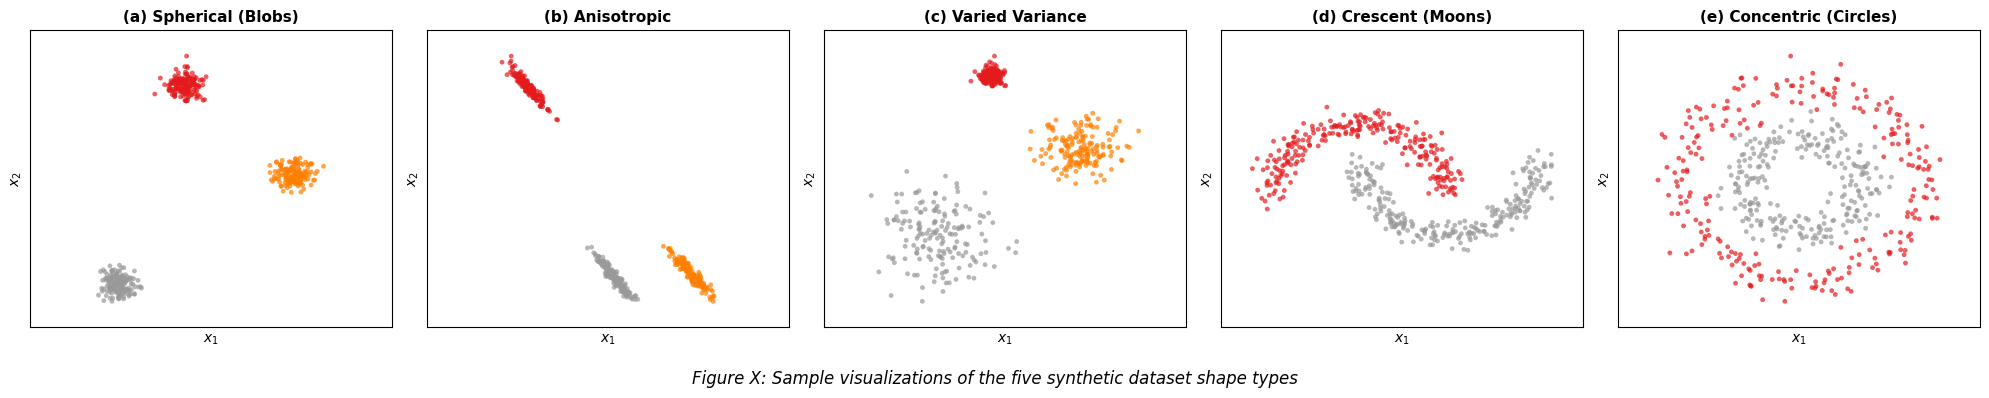

In [32]:
datasets = [
    (X_blobs, y_blobs, '(a) Spherical (Blobs)'),
    (X_aniso, y_aniso, '(b) Anisotropic'),
    (X_var, y_var, '(c) Varied Variance'),
    (X_moons, y_moons, '(d) Crescent (Moons)'),
    (X_circles, y_circles, '(e) Concentric (Circles)'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', s=12, alpha=0.7, edgecolors='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('$x_1$', fontsize=10)
    ax.set_ylabel('$x_2$', fontsize=10)
    
    # Normalize subplot bounds to square
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    max_range = max(xmax - xmin, ymax - ymin) * 1.1
    xmid, ymid = (xmin + xmax) / 2, (ymin + ymax) / 2
    ax.set_xlim(xmid - max_range/2, xmid + max_range/2)
    ax.set_ylim(ymid - max_range/2, ymid + max_range/2)

fig.suptitle('Figure X: Sample visualizations of the five synthetic dataset shape types',
             fontsize=12, y=-0.02, fontstyle='italic')

plt.tight_layout()
plt.savefig('synthetic_shapes_figure.png', dpi=300, bbox_inches='tight',
            facecolor='white', pad_inches=0.2)
plt.show()

## Individual Shape Details
Larger plots of each shape type for closer inspection.

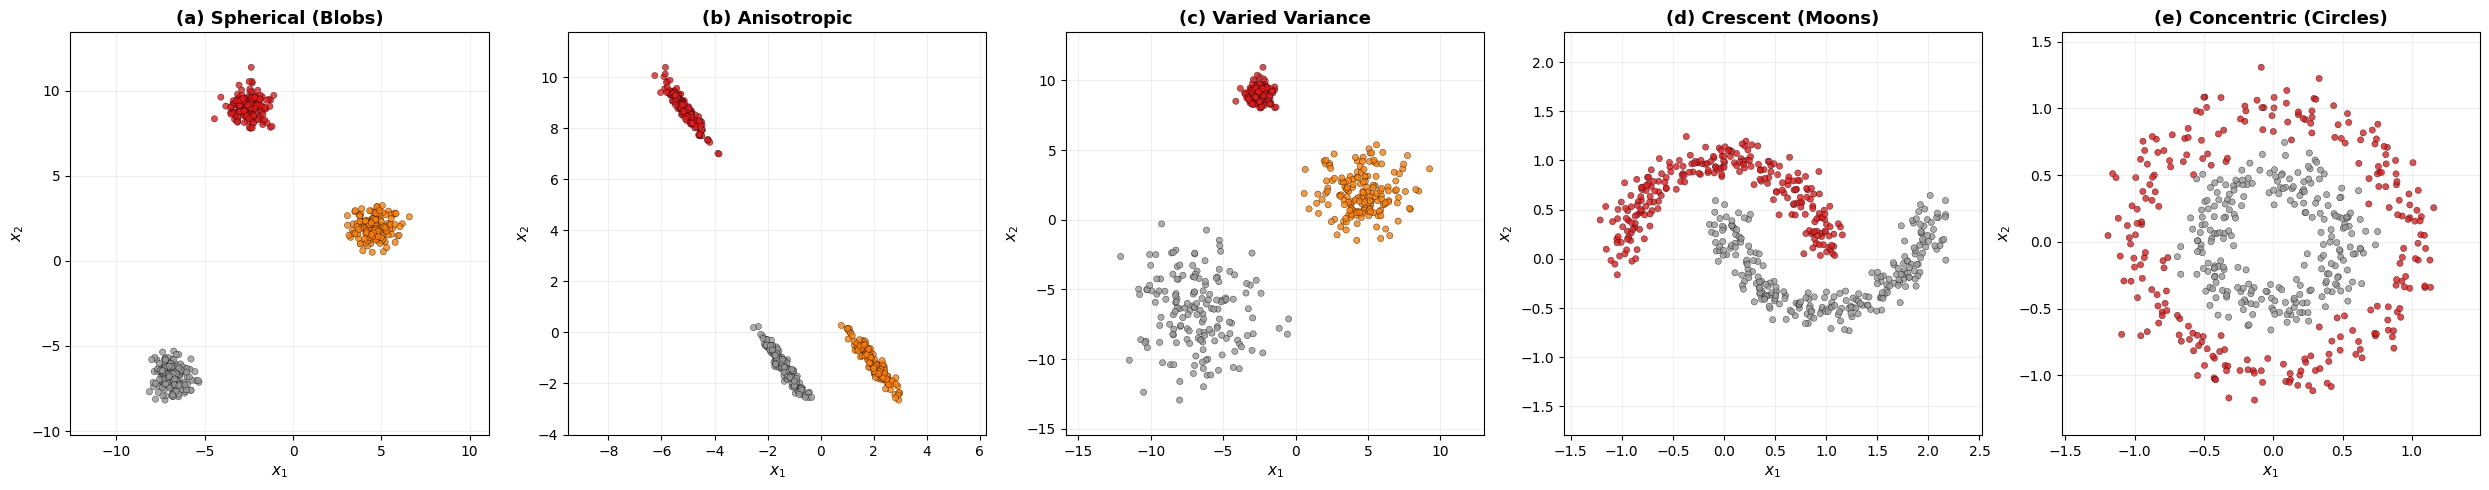

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (X, y, title) in zip(axes, datasets):
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', s=20, alpha=0.8, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.grid(True, alpha=0.2)
    
    # Normalize subplot bounds to square
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    max_range = max(xmax - xmin, ymax - ymin) * 1.1
    xmid, ymid = (xmin + xmax) / 2, (ymin + ymax) / 2
    ax.set_xlim(xmid - max_range/2, xmid + max_range/2)
    ax.set_ylim(ymid - max_range/2, ymid + max_range/2)

plt.tight_layout()
plt.savefig('synthetic_shapes_detailed.png', dpi=300, bbox_inches='tight',
            facecolor='white', pad_inches=0.2)
plt.show()

## Dataset Summary Statistics

In [34]:
print(f"{'Shape':<22} {'Samples':>8} {'Features':>9} {'Clusters':>9}")
print('-' * 52)
for X, y, title in datasets:
    name = title.split(') ')[1]
    n_clusters = len(np.unique(y))
    print(f"{name:<22} {X.shape[0]:>8} {X.shape[1]:>9} {n_clusters:>9}")

Shape                   Samples  Features  Clusters
----------------------------------------------------
Spherical (Blobs)           500         2         3
Anisotropic                 500         2         3
Varied Variance             500         2         3
Crescent (Moons)            500         2         2
Concentric (Circles)        500         2         2
